In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(42)
np.random.seed(42)

In [94]:
df = pd.read_csv("food_vendor.csv")
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget value counts:")
print(y.value_counts())

Dataset Shape: (1000, 10)

First few rows:
   foot_traffic  avg_income  competitor_count  rent_cost  population_density  \
0         699.0        81.0                 3      138.4                68.9   
1         572.0        73.9                 6      100.8                93.1   
2         730.0        60.9                 4       72.9                60.1   
3         905.0        50.3                 6      148.2                61.1   
4         553.0        70.5                 9      107.1                77.2   

   parking_score  visibility_score  hygiene_rating  marketing_score  \
0              2                 2             4.1             81.7   
1              6                 2             4.9             55.4   
2              3                 6             2.4             73.8   
3              2                 1             2.6             63.0   
4              1                 6             4.6             67.3   

   vendor_category  
0                0  
1      

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining target value counts:")
print(y_train.value_counts())
print("\nTest target value counts:")
print(y_test.value_counts())

Training set shape: (800, 9)
Test set shape: (200, 9)

Training target value counts:
vendor_category
2    272
0    264
1    264
Name: count, dtype: int64

Test target value counts:
vendor_category
2    68
1    66
0    66
Name: count, dtype: int64


In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training features scaled shape:", X_train_scaled.shape)
print("Test features scaled shape:", X_test_scaled.shape)

Training features scaled shape: (800, 9)
Test features scaled shape: (200, 9)


In [97]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 835 (3.26 KB)

 Trainable params: 835 (3.26 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4600 - loss: 1.0903   
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5163 - loss: 0.9777
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5700 - loss: 0.9087
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5987 - loss: 0.8614
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6175 - loss: 0.8284 
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6187 - loss: 0.8048 
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6363 - loss: 0.7878 
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6438 - loss: 0.7754 
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6463 - loss: 0.7661 
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6513 - loss: 0.7588 
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6525 - loss: 0.7532 
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

In [99]:
y_pred = model.predict(X_test_scaled)
y_pred_labels = np.argmax(y_pred, axis=1)
print(y_pred_labels)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[0 1 0 1 1 1 2 1 0 2 0 1 0 0 1 0 0 1 1 0 0 0 0 1 2 2 0 0 2 0 2 2 0 0 0 0 1
 0 0 2 0 2 0 2 0 1 2 2 0 2 1 2 1 1 0 0 1 2 0 0 1 1 1 2 2 0 2 2 1 2 2 1 1 1
 0 1 2 1 0 2 1 2 2 0 1 2 2 2 1 0 2 1 1 2 1 1 2 0 1 0 1 2 1 2 1 2 0 0 2 2 0
 2 1 2 1 1 1 2 1 2 2 0 2 1 2 0 0 1 1 0 1 1 0 0 2 0 0 0 1 2 1 0 2 1 0 2 1 0
 1 1 1 0 2 0 2 1 1 0 0 0 0 0 2 0 0 0 1 2 0 0 0 1 2 1 2 0 2 1 2 2 1 0 2 0 2
 1 0 1 2 1 1 0 2 0 1 0 2 2 0 1]


In [100]:
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.5350


In [101]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.68      0.65        66
           1       0.35      0.35      0.35        66
           2       0.63      0.57      0.60        68

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.54      0.54      0.53       200



In [102]:
cm = confusion_matrix(y_test, y_pred_labels)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[45 17  4]
 [24 23 19]
 [ 3 26 39]]


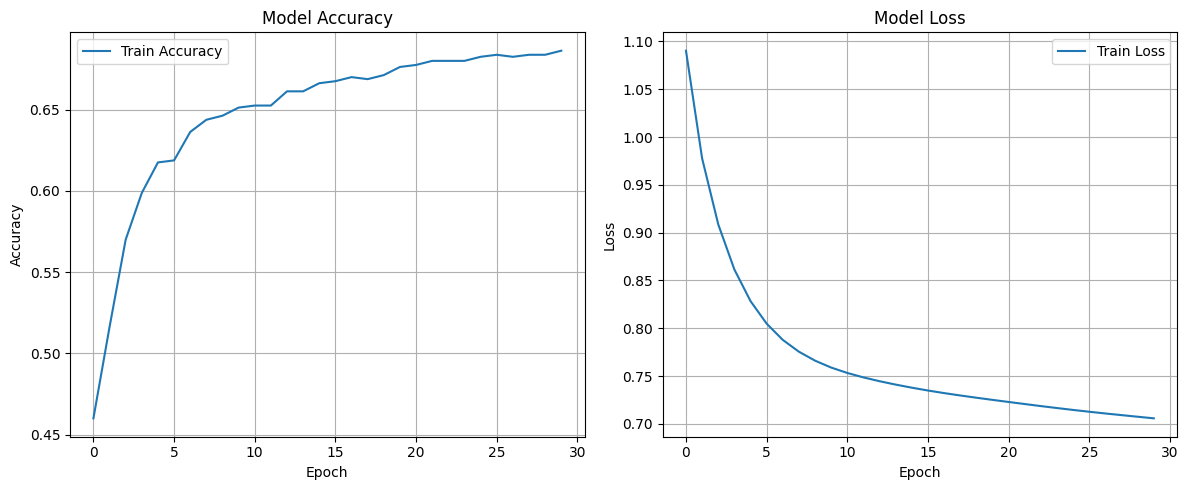

In [103]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

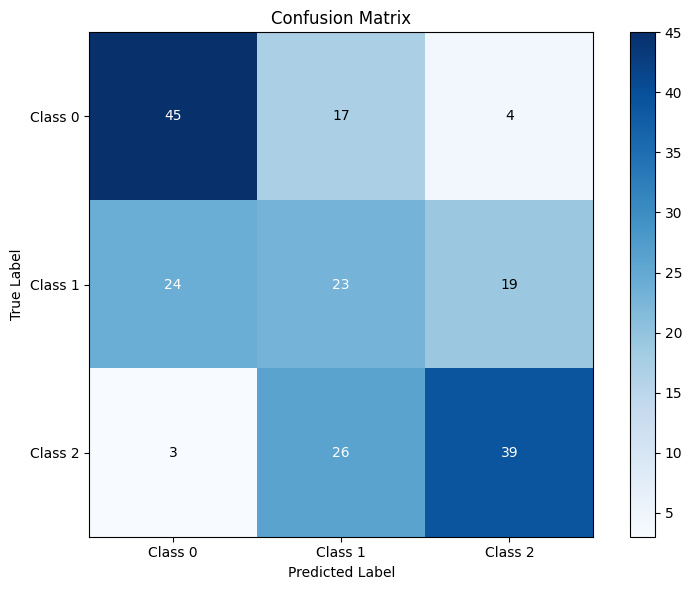

In [104]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(3)
plt.xticks(tick_marks, ['Class 0', 'Class 1', 'Class 2'])
plt.yticks(tick_marks, ['Class 0', 'Class 1', 'Class 2'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()